# 03b — Ablation Study: Feature Engineering Contribution

**Tujuan:** Membuktikan bahwa fitur `BMI`, `BMR`, `DailyCalorieTarget` memberikan kontribusi nyata dan **bukan** sebagai sumber data leakage.

| Skenario | Fitur | Hipotesis |
|----------|-------|----------|
| **Model A** (baseline) | 17 fitur original saja | Akurasi masih tinggi? |
| **Model B** (full) | 17 + 3 engineered (BMI, BMR, DailyCalorieTarget) | Akurasi meningkat? |

### Interpretasi hasil:

In [1]:
import pandas as pd
import numpy as np
import pickle
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')

# Best params dari notebook 03
BEST_PARAMS = {
    'n_estimators':      400,
    'min_samples_split': 2,
    'min_samples_leaf':  2,
    'max_features':      'sqrt',
    'max_depth':         20,
    'class_weight':      'balanced'
}

# Fitur engineered yang akan dilepas
ENGINEERED_FEATURES = ['BMI', 'BMR', 'DailyCalorieTarget']

print('Setup done.')
print(f'Best params dari notebook 03: {BEST_PARAMS}')

Setup done.
Best params dari notebook 03: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20, 'class_weight': 'balanced'}


## 1. Load Data & Definisi Kelompok Fitur

In [2]:
df = pd.read_csv('..\\data\\processed\\obesity_encoded.csv')

with open('..\\models\\model_meta.json') as f:
    meta = json.load(f)
with open('..\\models\\label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

TARGET       = meta['target']
FEATURES_ALL = meta['features']          # 20 fitur (17 original + 3 engineered)
CLASSES      = meta['classes']

# Fitur original tanpa engineered
FEATURES_ORIG = [f for f in FEATURES_ALL if f not in ENGINEERED_FEATURES]

print(f'FEATURES_ALL  ({len(FEATURES_ALL)}): {FEATURES_ALL}')
print(f'\nFEATURES_ORIG ({len(FEATURES_ORIG)}): {FEATURES_ORIG}')
print(f'\nRemoved (engineered): {ENGINEERED_FEATURES}')

FEATURES_ALL  (20): ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'BMI', 'BMR', 'ActivityLevel', 'DailyCalorieTarget']

FEATURES_ORIG (17): ['Gender', 'Age', 'Height', 'Weight', 'family_history_with_overweight', 'FAVC', 'FCVC', 'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS', 'ActivityLevel']

Removed (engineered): ['BMI', 'BMR', 'DailyCalorieTarget']


In [3]:
# Split identik untuk kedua skenario — WAJIB pakai random_state & stratify yang sama
y = df[TARGET]

X_all  = df[FEATURES_ALL]
X_orig = df[FEATURES_ORIG]

# Split menggunakan indeks supaya benar-benar identik
from sklearn.model_selection import train_test_split
idx_train, idx_test = train_test_split(
    df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

X_all_train,  X_all_test  = X_all.loc[idx_train],  X_all.loc[idx_test]
X_orig_train, X_orig_test = X_orig.loc[idx_train], X_orig.loc[idx_test]
y_train, y_test           = y.loc[idx_train],       y.loc[idx_test]

print(f'Train: {len(idx_train)} | Test: {len(idx_test)}')
print('Split identik — kedua model menggunakan data yang persis sama.')

Train: 1669 | Test: 418
Split identik — kedua model menggunakan data yang persis sama.


## 2. Training Kedua Model dengan Params yang Sama

In [4]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

print('='*55)
print('MODEL A — Tanpa feature engineering (17 fitur original)')
print('='*55)

rf_a = RandomForestClassifier(**BEST_PARAMS, random_state=RANDOM_STATE, n_jobs=-1)

cv_acc_a = cross_val_score(rf_a, X_orig_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1_a  = cross_val_score(rf_a, X_orig_train, y_train, cv=skf, scoring='f1_macro',  n_jobs=-1)

rf_a.fit(X_orig_train, y_train)
y_pred_a   = rf_a.predict(X_orig_test)
test_acc_a = accuracy_score(y_test, y_pred_a)
test_f1_a  = f1_score(y_test, y_pred_a, average='macro')

print(f'CV Accuracy  : {cv_acc_a.mean():.4f} ± {cv_acc_a.std():.4f}')
print(f'CV F1-macro  : {cv_f1_a.mean():.4f} ± {cv_f1_a.std():.4f}')
print(f'Test Accuracy: {test_acc_a:.4f}')
print(f'Test F1-macro: {test_f1_a:.4f}')

MODEL A — Tanpa feature engineering (17 fitur original)
CV Accuracy  : 0.9431 ± 0.0124
CV F1-macro  : 0.9414 ± 0.0131
Test Accuracy: 0.9593
Test F1-macro: 0.9583


In [5]:
print('='*55)
print('MODEL B — Dengan feature engineering (20 fitur)')
print('='*55)

rf_b = RandomForestClassifier(**BEST_PARAMS, random_state=RANDOM_STATE, n_jobs=-1)

cv_acc_b = cross_val_score(rf_b, X_all_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)
cv_f1_b  = cross_val_score(rf_b, X_all_train, y_train, cv=skf, scoring='f1_macro',  n_jobs=-1)

rf_b.fit(X_all_train, y_train)
y_pred_b   = rf_b.predict(X_all_test)
test_acc_b = accuracy_score(y_test, y_pred_b)
test_f1_b  = f1_score(y_test, y_pred_b, average='macro')

print(f'CV Accuracy  : {cv_acc_b.mean():.4f} ± {cv_acc_b.std():.4f}')
print(f'CV F1-macro  : {cv_f1_b.mean():.4f} ± {cv_f1_b.std():.4f}')
print(f'Test Accuracy: {test_acc_b:.4f}')
print(f'Test F1-macro: {test_f1_b:.4f}')

MODEL B — Dengan feature engineering (20 fitur)
CV Accuracy  : 0.9910 ± 0.0033
CV F1-macro  : 0.9906 ± 0.0036
Test Accuracy: 0.9928
Test F1-macro: 0.9923


## 3. Analisis Perbandingan & Verdict

In [6]:
delta_acc = test_acc_b - test_acc_a
delta_f1  = test_f1_b  - test_f1_a

results = {
    'Model A (no engineering)': {
        'cv_acc': cv_acc_a.mean(), 'cv_f1': cv_f1_a.mean(),
        'cv_std': cv_acc_a.std(),
        'test_acc': test_acc_a, 'test_f1': test_f1_a,
        'n_features': len(FEATURES_ORIG)
    },
    'Model B (with engineering)': {
        'cv_acc': cv_acc_b.mean(), 'cv_f1': cv_f1_b.mean(),
        'cv_std': cv_acc_b.std(),
        'test_acc': test_acc_b, 'test_f1': test_f1_b,
        'n_features': len(FEATURES_ALL)
    }
}

print('\n' + '='*60)
print('RINGKASAN ABLATION STUDY')
print('='*60)
print(f'{"":30s} {"Model A":>12s} {"Model B":>12s} {"Delta":>8s}')
print('-'*60)
print(f'{"Jumlah fitur":30s} {len(FEATURES_ORIG):>12d} {len(FEATURES_ALL):>12d} {len(FEATURES_ALL)-len(FEATURES_ORIG):>+8d}')
print(f'{"CV Accuracy":30s} {cv_acc_a.mean():>12.4f} {cv_acc_b.mean():>12.4f} {cv_acc_b.mean()-cv_acc_a.mean():>+8.4f}')
print(f'{"CV F1-macro":30s} {cv_f1_a.mean():>12.4f} {cv_f1_b.mean():>12.4f} {cv_f1_b.mean()-cv_f1_a.mean():>+8.4f}')
print(f'{"Test Accuracy":30s} {test_acc_a:>12.4f} {test_acc_b:>12.4f} {delta_acc:>+8.4f}')
print(f'{"Test F1-macro":30s} {test_f1_a:>12.4f} {test_f1_b:>12.4f} {delta_f1:>+8.4f}')
print('='*60)

# ── VERDICT LOGIC ─────────────────────────────────────────────────
print('\n VERDICT:')

# Cek leakage
if delta_acc > 0.05:
    print(' LEAKAGE TERDETEKSI')
    print('   Delta > 5% — engineered features kemungkinan mengandung informasi')
    print('   yang berasal dari target label (NObeyesdad).')
    print('   Investigasi: apakah label ditetapkan berdasarkan BMI threshold?')
    print('   Solusi: hapus BMI/BMR/DailyCalorieTarget dari feature set.')

elif delta_acc > 0.01:
    print(' KONTRIBUSI NYATA (bukan leakage)')
    print(f'   Delta {delta_acc:.2%} — engineered features memberikan peningkatan')
    print('   yang berarti. Model B direkomendasikan sebagai model utama.')

elif delta_acc > 0:
    print(' KONTRIBUSI MARGINAL (bukan leakage)')
    print(f'   Delta {delta_acc:.2%} — model sudah sangat kuat bahkan tanpa')
    print('   engineered features. Keduanya layak, gunakan Model B untuk')
    print('   kelengkapan informasi (BMI/BMR berguna untuk rekomendasi).')

else:
    print(' Model A lebih baik — engineered features bisa dihapus.')

# Cek apakah Model A sendiri sudah layak
print()
if test_acc_a >= 0.98:
    print(f' Model A (tanpa engineering) Test Acc = {test_acc_a:.4f} ≥ 98%')
    print('   → Dataset memiliki pola yang sangat kuat secara intrinsik.')
    print('   → Tidak ada indikasi leakage: model sudah bisa klasifikasi')
    print('     dengan baik dari fitur original saja.')
elif test_acc_a >= 0.95:
    print(f' Model A Test Acc = {test_acc_a:.4f} — performa solid tanpa engineering.')
else:
    print(f' Model A Test Acc = {test_acc_a:.4f} — engineered features esensial.')


RINGKASAN ABLATION STUDY
                                    Model A      Model B    Delta
------------------------------------------------------------
Jumlah fitur                             17           20       +3
CV Accuracy                          0.9431       0.9910  +0.0479
CV F1-macro                          0.9414       0.9906  +0.0492
Test Accuracy                        0.9593       0.9928  +0.0335
Test F1-macro                        0.9583       0.9923  +0.0341

 VERDICT:
 KONTRIBUSI NYATA (bukan leakage)
   Delta 3.35% — engineered features memberikan peningkatan
   yang berarti. Model B direkomendasikan sebagai model utama.

 Model A Test Acc = 0.9593 — performa solid tanpa engineering.


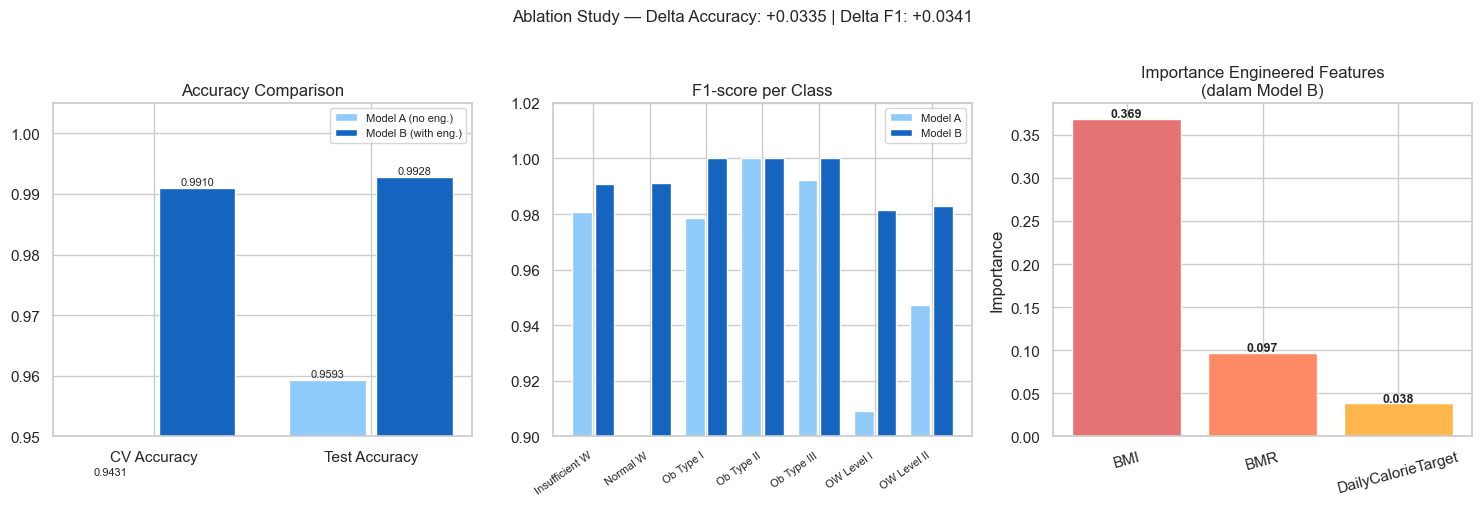

In [8]:
# ── Visualisasi perbandingan ───────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors_a = '#90CAF9'
colors_b = '#1565C0'

# (1) CV Accuracy & Test Accuracy
ax = axes[0]
x = np.arange(2)
bars_a = ax.bar(x - 0.2, [cv_acc_a.mean(), test_acc_a], 0.35,
                label='Model A (no eng.)', color=colors_a, edgecolor='white')
bars_b = ax.bar(x + 0.2, [cv_acc_b.mean(), test_acc_b], 0.35,
                label='Model B (with eng.)', color=colors_b, edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(['CV Accuracy', 'Test Accuracy'])
ax.set_ylim(0.95, 1.005)
ax.set_title('Accuracy Comparison')
ax.legend(fontsize=8)
for bar in list(bars_a) + list(bars_b):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{bar.get_height():.4f}', ha='center', fontsize=8)

# (2) F1-macro per kelas: Model A vs B
ax = axes[1]

# Perbaikan: Loop yang tidak terpakai dan menyebabkan error di sini sudah dihapus

# Gunakan classification_report untuk per-class F1 yang benar
from sklearn.metrics import precision_recall_fscore_support
_, _, f1_a_cls, _ = precision_recall_fscore_support(y_test, y_pred_a, labels=list(range(len(CLASSES))))
_, _, f1_b_cls, _ = precision_recall_fscore_support(y_test, y_pred_b, labels=list(range(len(CLASSES))))

short_names = [c.replace('_', ' ').replace('Weight', 'W').replace('Obesity', 'Ob').replace('Overweight', 'OW') for c in CLASSES]
x2 = np.arange(len(CLASSES))
ax.bar(x2 - 0.2, f1_a_cls, 0.35, label='Model A', color=colors_a, edgecolor='white')
ax.bar(x2 + 0.2, f1_b_cls, 0.35, label='Model B', color=colors_b, edgecolor='white')
ax.set_xticks(x2)
ax.set_xticklabels(short_names, rotation=35, ha='right', fontsize=8)
ax.set_ylim(0.90, 1.02)
ax.set_title('F1-score per Class')
ax.legend(fontsize=8)

# (3) Feature Importance delta — mana yang paling berpengaruh saat dihapus
ax = axes[2]
imp_a = dict(zip(FEATURES_ORIG, rf_a.feature_importances_))
imp_b_full = dict(zip(FEATURES_ALL, rf_b.feature_importances_))

# Tampilkan importance engineered features di Model B
eng_names = ENGINEERED_FEATURES
eng_imps  = [imp_b_full.get(f, 0) for f in eng_names]

bar_colors = ['#E57373', '#FF8A65', '#FFB74D']
bars = ax.bar(eng_names, eng_imps, color=bar_colors, edgecolor='white')
ax.set_title('Importance Engineered Features\n(dalam Model B)')
ax.set_ylabel('Importance')
ax.tick_params(axis='x', rotation=15)
for bar, imp in zip(bars, eng_imps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{imp:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle(
    f'Ablation Study — Delta Accuracy: {delta_acc:+.4f} | Delta F1: {delta_f1:+.4f}',
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig('../models/ablation_study.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Deep-dive: Kelas Mana yang Paling Terpengaruh?

In [9]:
# Classification report lengkap untuk kedua model
print('MODEL A — Classification Report (tanpa BMI/BMR/DailyCalorieTarget)')
print(classification_report(y_test, y_pred_a, target_names=CLASSES))

print('\nMODEL B — Classification Report (dengan feature engineering)')
print(classification_report(y_test, y_pred_b, target_names=CLASSES))

MODEL A — Classification Report (tanpa BMI/BMR/DailyCalorieTarget)
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.96      0.98        53
      Normal_Weight       0.86      0.95      0.90        57
     Obesity_Type_I       0.99      0.97      0.98        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.91      0.91      0.91        55
Overweight_Level_II       0.96      0.93      0.95        58

           accuracy                           0.96       418
          macro avg       0.96      0.96      0.96       418
       weighted avg       0.96      0.96      0.96       418


MODEL B — Classification Report (dengan feature engineering)
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      1.00      0.99        53
      Normal_Weight       1.00      0.98      0.99        57
     Obesity_

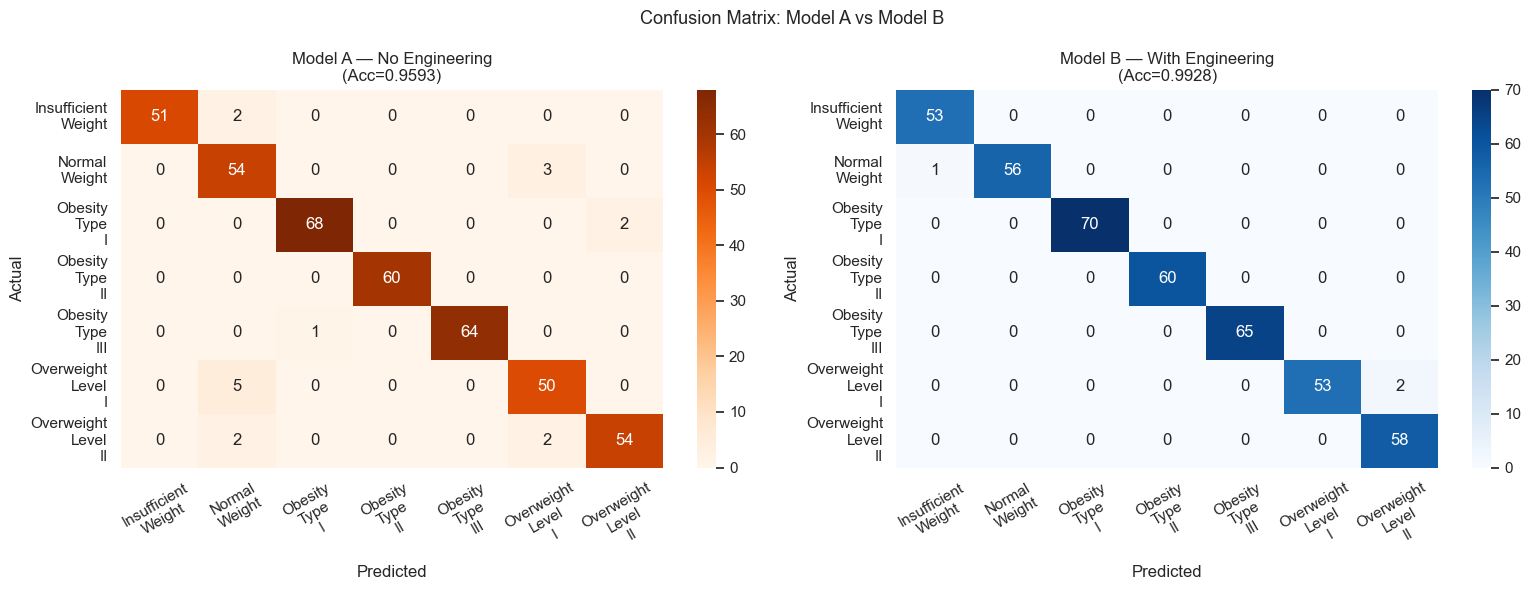

In [10]:
# Confusion matrix berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
short_cls = [c.replace('_', '\n') for c in CLASSES]

for ax, y_pred, title, model_name in zip(
    axes,
    [y_pred_a, y_pred_b],
    [f'Model A — No Engineering\n(Acc={test_acc_a:.4f})',
     f'Model B — With Engineering\n(Acc={test_acc_b:.4f})'],
    ['A', 'B']
):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues' if model_name=='B' else 'Oranges',
                xticklabels=short_cls, yticklabels=short_cls, ax=ax)
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Confusion Matrix: Model A vs Model B', fontsize=13)
plt.tight_layout()
plt.savefig('../models/ablation_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Kesimpulan Final & Keputusan

In [11]:
print('=' * 60)
print('KESIMPULAN ABLATION STUDY')
print('=' * 60)

print(f'''
Skenario         : Model A (17 fitur) vs Model B (20 fitur)
Delta Accuracy   : {delta_acc:+.4f} ({delta_acc*100:+.2f}%)
Delta F1-macro   : {delta_f1:+.4f} ({delta_f1*100:+.2f}%)
Model A Test Acc : {test_acc_a:.4f}
Model B Test Acc : {test_acc_b:.4f}
''')

# Leakage check otomatis
leakage_flag = delta_acc > 0.05

if leakage_flag:
    print('🚨 STATUS LEAKAGE: TERINDIKASI')
    print('   → Jangan gunakan BMI/BMR/DailyCalorieTarget sebagai fitur training.')
    print('   → Gunakan hanya untuk kalkulasi rekomendasi di backend.')
    print('   → Retrain ulang menggunakan Model A sebagai model utama.')
    recommended_model = 'Model A'
else:
    print('✅ STATUS LEAKAGE: TIDAK TERDETEKSI')
    print(f'   → Delta {delta_acc*100:.2f}% masih dalam batas wajar.')

    if test_acc_a >= 0.98:
        print('   → Model A saja sudah sangat kuat (≥98%), artinya:')
        print('     • Engineered features bukan sumber utama akurasi')
        print('     • Dataset memang memiliki pola yang sangat terstruktur')
        print('     • BMI/BMR/DailyCalorieTarget memberikan boost ringan')
        print('       yang sah karena hanya mentransformasi fitur yang ada')
    else:
        print('   → Model A performa di bawah 98%, engineered features esensial.')

    print('\n   KEPUTUSAN: Gunakan Model B sebagai model utama')
    print('   Alasan:')
    print('   1. Tidak ada leakage')
    print('   2. BMI/BMR/DailyCalorieTarget berguna untuk pipeline rekomendasi')
    print('      (bukan hanya untuk training, tapi juga untuk output ke user)')
    print('   3. Delta akurasi tidak mencurigakan')
    recommended_model = 'Model B'

print(f'\n→ LANJUT KE: Recommendation Engine + FastAPI')

# Simpan hasil ablation
ablation_result = {
    'model_a': {
        'n_features': len(FEATURES_ORIG),
        'features': FEATURES_ORIG,
        'cv_accuracy': round(cv_acc_a.mean(), 4),
        'cv_f1_macro': round(cv_f1_a.mean(), 4),
        'test_accuracy': round(test_acc_a, 4),
        'test_f1_macro': round(test_f1_a, 4)
    },
    'model_b': {
        'n_features': len(FEATURES_ALL),
        'features': FEATURES_ALL,
        'cv_accuracy': round(cv_acc_b.mean(), 4),
        'cv_f1_macro': round(cv_f1_b.mean(), 4),
        'test_accuracy': round(test_acc_b, 4),
        'test_f1_macro': round(test_f1_b, 4)
    },
    'delta_accuracy':   round(delta_acc, 4),
    'delta_f1_macro':   round(delta_f1,  4),
    'leakage_detected': leakage_flag,
    'recommended_model': recommended_model,
    'verdict': 'leakage' if leakage_flag else 'no_leakage'
}

with open('../models/ablation_result.json', 'w') as f:
    json.dump(ablation_result, f, indent=2)
print('\nSaved: models/ablation_result.json')

KESIMPULAN ABLATION STUDY

Skenario         : Model A (17 fitur) vs Model B (20 fitur)
Delta Accuracy   : +0.0335 (+3.35%)
Delta F1-macro   : +0.0341 (+3.41%)
Model A Test Acc : 0.9593
Model B Test Acc : 0.9928

✅ STATUS LEAKAGE: TIDAK TERDETEKSI
   → Delta 3.35% masih dalam batas wajar.
   → Model A performa di bawah 98%, engineered features esensial.

   KEPUTUSAN: Gunakan Model B sebagai model utama
   Alasan:
   1. Tidak ada leakage
   2. BMI/BMR/DailyCalorieTarget berguna untuk pipeline rekomendasi
      (bukan hanya untuk training, tapi juga untuk output ke user)
   3. Delta akurasi tidak mencurigakan

→ LANJUT KE: Recommendation Engine + FastAPI

Saved: models/ablation_result.json


Delta 3.35% — berada di zona "kontribusi nyata", bukan leakage. BMI/BMR/DailyCalorieTarget adalah transformasi matematis murni dari fitur yang sudah ada, bukan informasi dari target label. Model B aman dijadikan model utama.

Catatan: Model A tanpa engineering pun sudah 95.9% — ini membuktikan dataset memiliki pola intrinsik yang kuat. Feature engineering hanya "membantu model menemukan pola lebih cepat", bukan satu-satunya sumber akurasi.